In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

np.random.seed(42)


In [2]:

df = pd.read_csv(r"E:\my research\algo local\Cardiosense\swat_heart_disease_dataset.csv")

df.drop(columns=['ecg', 'rwma', 'trop', 'angio'], inplace=True)
df.drop_duplicates(inplace=True)

X = df.drop(columns='target')
y = df['target']


In [3]:
transformer = ColumnTransformer(
    transformers=[
        ('age_scaling', MinMaxScaler(), ['age']),

        ('categorical_encoding',
         OneHotEncoder(drop='first'),
         ['sex', 'diabetes', 'fhist']),

        ('cp_encoding',
         OrdinalEncoder(categories=[[
             'No Angina',
             'Stable Angina',
             'Unstable Angina'
         ]]),
         ['cp']),

        ('bp_encoding',
         OrdinalEncoder(categories=[[
             'Normal',
             'Low',
             'High'
         ]]),
         ['BP']),

        ('activity_encoding',
         OrdinalEncoder(categories=[[
             'High',
             'Moderate',
             'Low'
         ]]),
         ['Physical_Activity'])
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [4]:
model = Pipeline([
    ('preprocessing', transformer),
    ('classifier', SGDClassifier(random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [5]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='Yes'),
    'Recall': recall_score(y_test, y_pred, pos_label='Yes'),
    'F1 Score': f1_score(y_test, y_pred, pos_label='Yes'),
    'ROC AUC': roc_auc_score(
        (y_test == 'Yes').astype(int),
        (y_pred == 'Yes').astype(int)
    )
}

print(f"Accuracy  : {metrics['Accuracy']:.4f}")
print(f"Precision : {metrics['Precision']:.4f}")
print(f"Recall    : {metrics['Recall']:.4f}")
print(f"F1 Score  : {metrics['F1 Score']:.4f}")
print(f"ROC AUC   : {metrics['ROC AUC']:.4f}")

cm = confusion_matrix(y_test, y_pred)


Accuracy  : 0.5227
Precision : 0.5435
Recall    : 0.5435
F1 Score  : 0.5435
ROC AUC   : 0.5217


Saved to: SGD/confusion_matrix.png


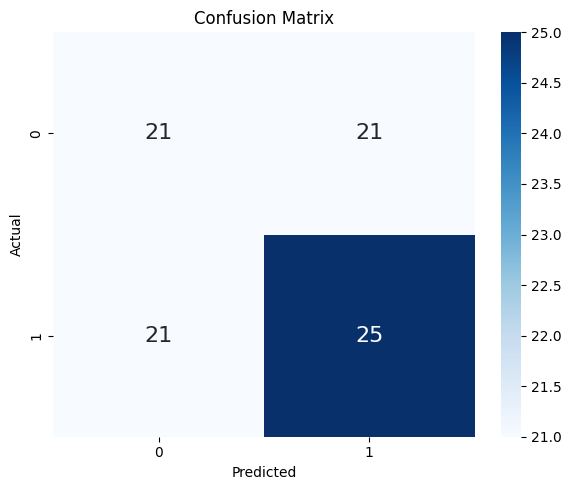

In [6]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size": 16}
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()

plt.savefig(
    "SGD/confusion_matrix.png",
    bbox_inches='tight',
    dpi=150
)

print("Saved to: SGD/confusion_matrix.png")

plt.show()

Saved to: SGD/SGD_performance.png


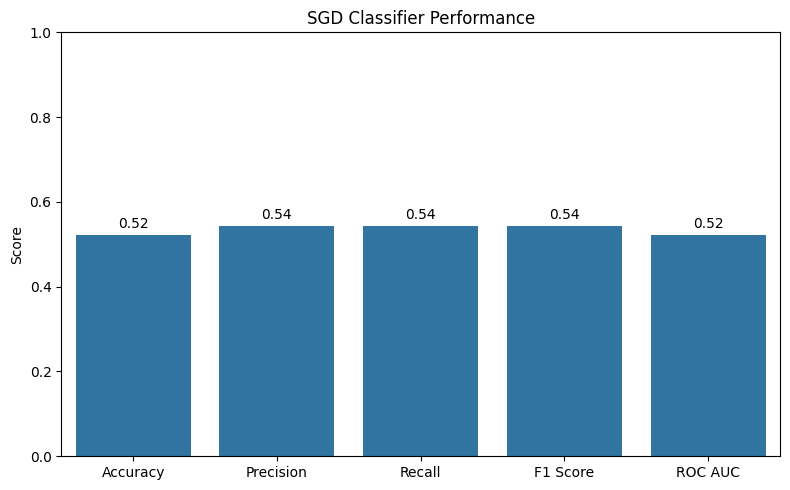

In [7]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values())
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("SGD Classifier Performance")

plt.tight_layout()

plt.savefig(
    "SGD/SGD_performance.png",
    bbox_inches='tight',
    dpi=150
)

print("Saved to: SGD/SGD_performance.png")

plt.show()